In [16]:
# Fix sys path to find modules in the project
import sys
sys.path.append("/Users/gccasini/GitHub/diplomatrixbr-eval")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [17]:
from scripts.utils import get_mean
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import yaml
import textwrap

In [18]:
filepath = "/Users/gccasini/GitHub/diplomatrixbr-eval/prompt_testing/sheets/sabia_p7-12.csv"

df_eval = get_mean(filepath)
df_eval["nota_final"] = df_eval["nota_final"].fillna(df_eval["faixa"])
df_eval.drop(columns=["faixa"], inplace=True)

df_eval[:24]

,judge,prompt,temp,redacao,nota_final,1A,1B,1C,CGPL,num_errors
0,sabia-3.1,7,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000
1,sabia-3.1,7,0.5,1,52.6333,8.6667,8.6667,18.0000,17.3000,2.3333
2,sabia-3.1,7,0.9,1,51.6333,8.6667,9.0000,17.3333,16.6333,2.3333
3,sabia-3.1,8,0.0,1,55.7500,NaN,NaN,NaN,NaN,0.0000
4,sabia-3.1,8,0.5,1,57.2500,NaN,NaN,NaN,NaN,0.3333
5,sabia-3.1,8,0.9,1,56.8333,NaN,NaN,NaN,NaN,0.6667
6,sabia-3.1,9,0.0,1,50.0000,NaN,NaN,NaN,NaN,0.0000
7,sabia-3.1,9,0.5,1,50.0000,NaN,NaN,NaN,NaN,0.0000
8,sabia-3.1,9,0.9,1,53.3333,NaN,NaN,NaN,NaN,0.0000
9,sabia-3.1,10,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000


In [19]:
df_human = pd.read_csv("/Users/gccasini/GitHub/diplomatrixbr-eval/prompt_testing/sheets/notas_humanas_2022.csv")
df_human.drop(columns=["versao", "prompt", "temp", "faixa"], inplace=True)

df_human

,judge,redacao,nota_final,1A,1B,1C,CGPL,num_errors
0,humano,1,55.5,10.0,9.5,18.0,18.0,0
1,humano,2,56.0,9.5,9.5,18.5,18.5,0
2,humano,3,58.0,10.0,10.0,19.0,19.0,0
3,humano,4,56.7,10.0,10.0,18.5,18.2,1
4,humano,5,54.7,9.5,9.5,18.0,17.7,1
5,humano,6,57.5,9.5,10.0,19.0,19.0,0


## Distribuição de Notas

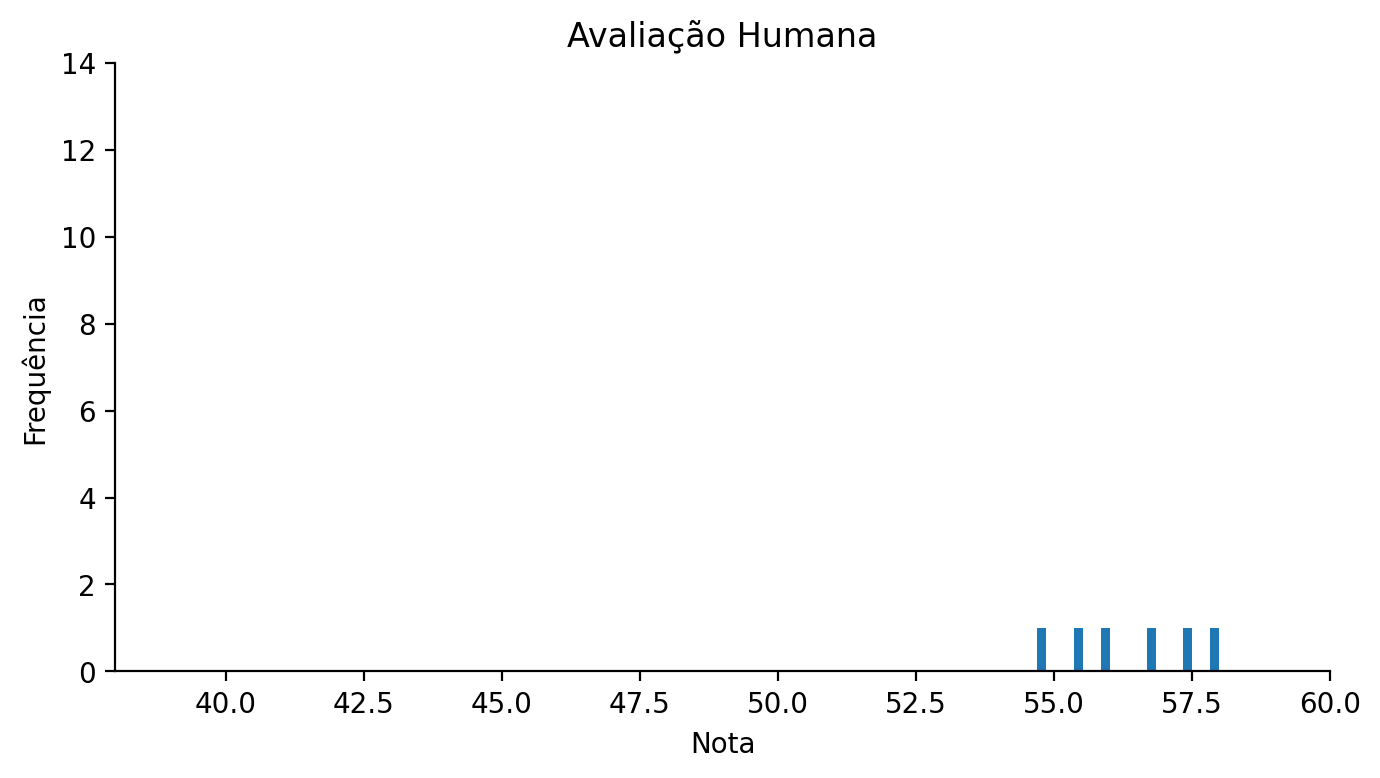

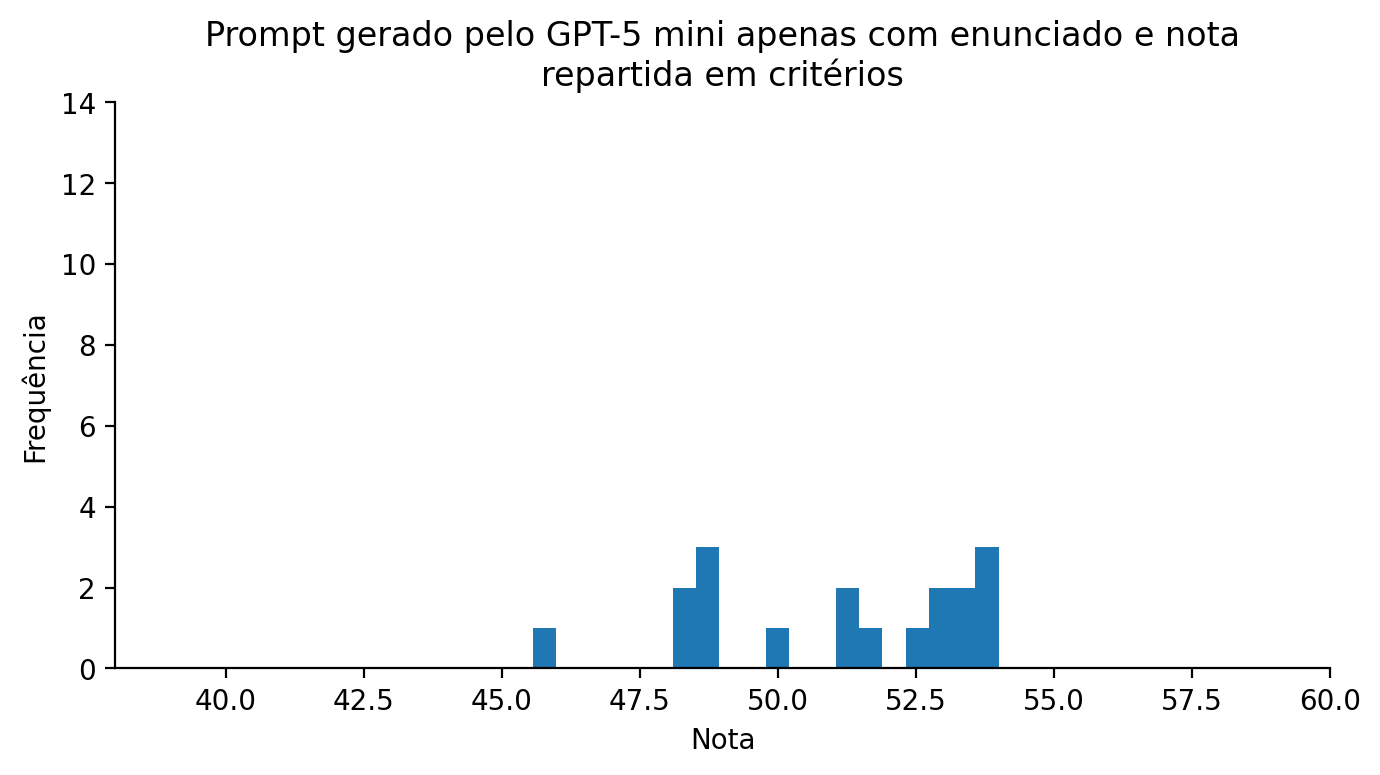

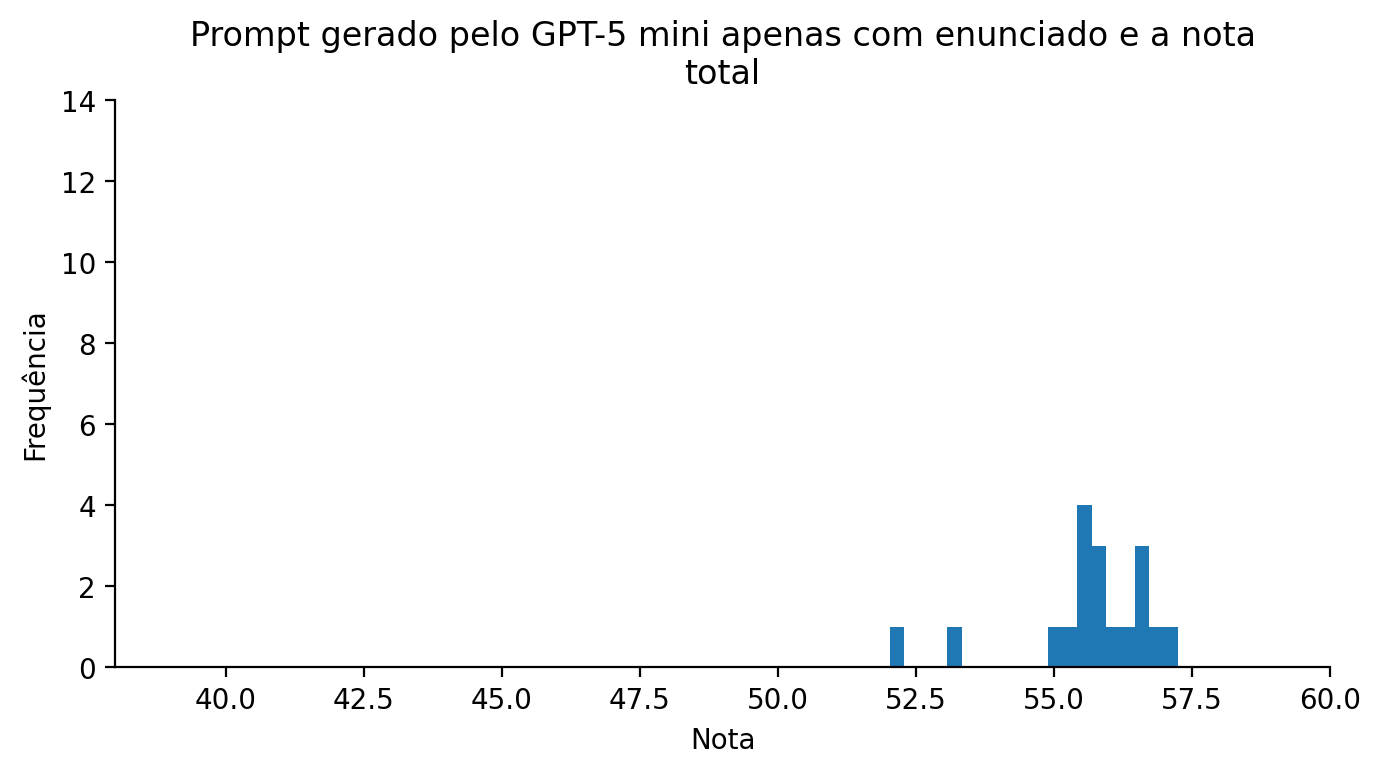

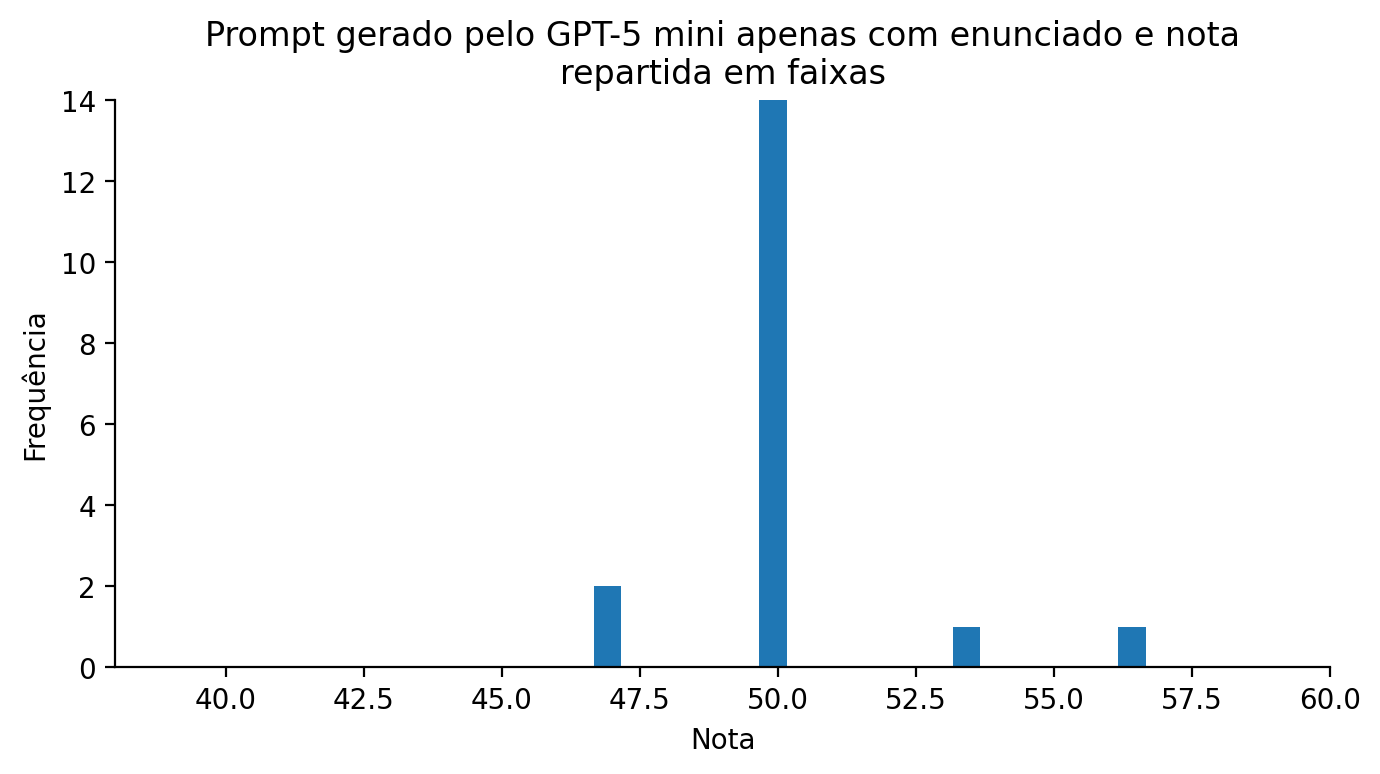

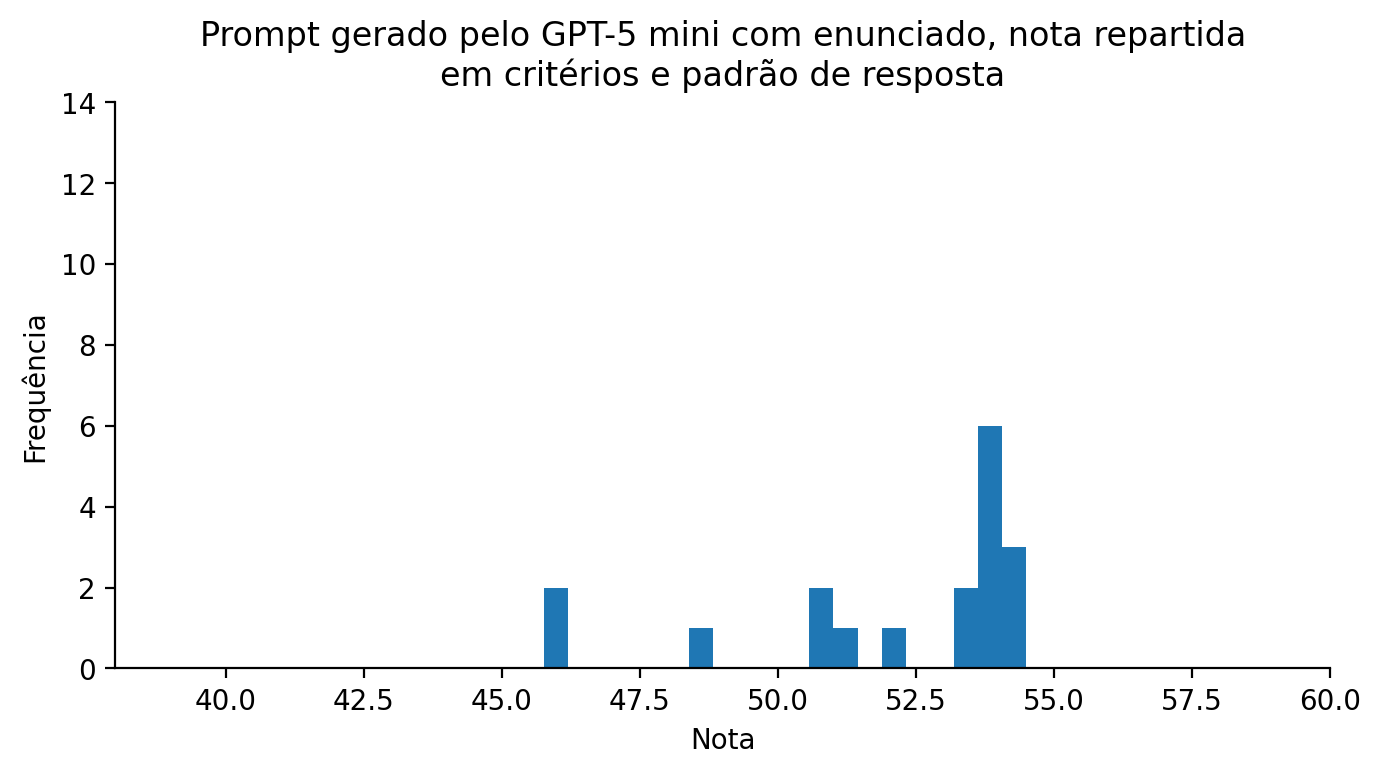

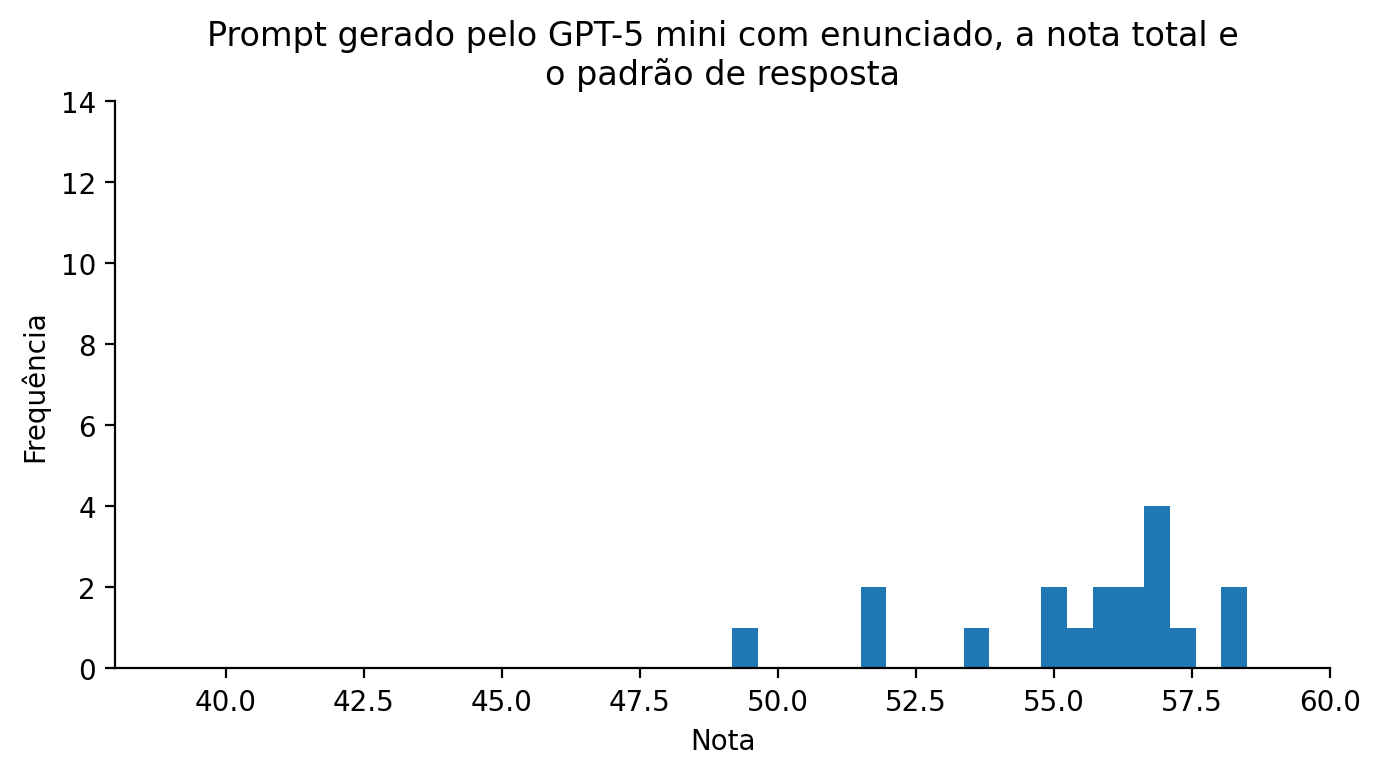

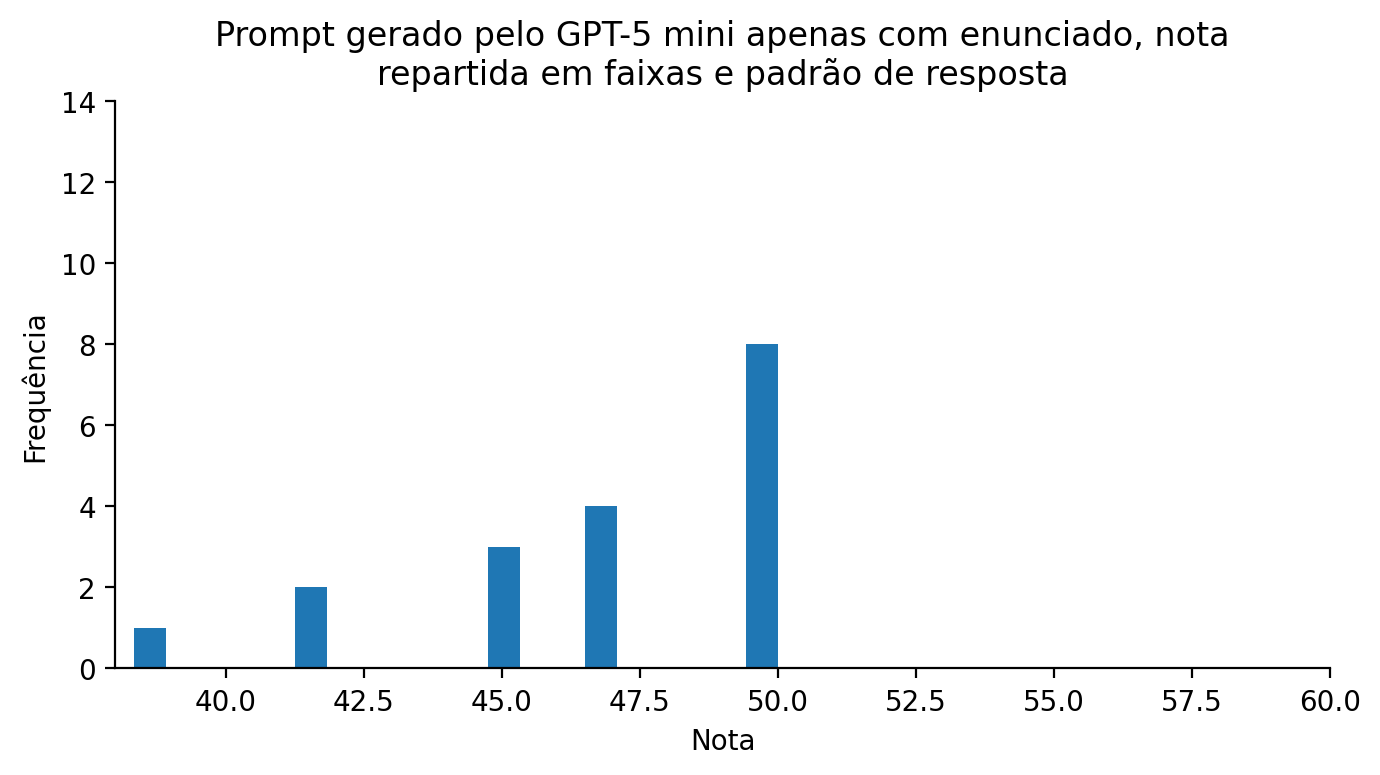

In [20]:
with open("/Users/gccasini/GitHub/diplomatrixbr-eval/prompt_testing/prompts.yaml", 'r', encoding='utf-8') as file:
    prompts_yaml = yaml.safe_load(file)
    prompts = prompts_yaml['prompts']

for i in [0, 7, 8, 9, 10, 11, 12]:

    if i == 0:
        subset = df_human
        title = "Avaliação Humana"
    else:
        subset = df_eval[df_eval['prompt'] == i]
        title = "\n".join(textwrap.wrap(prompts[i+1]["description"], width=60))
    plt.figure(figsize=(7, 4))

    subset['nota_final'].plot(
        kind='hist',
        bins=20,
        title=title,
        xlabel="Nota",
        ylabel="Frequência"
    )

    plt.xlim(38, 60)
    plt.ylim(0, 14)
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

In [21]:
df_merged = df_eval.merge(
    df_human[["redacao", "nota_final"]].rename(columns={"nota_final": "nota_humana"}),
    on="redacao"
)

df_merged["se"] = (df_merged["nota_humana"] - df_merged["nota_final"])**2

df_merged["rmse"] = df_merged.groupby(
    ["judge", "prompt", "temp", "redacao"]
)["se"].transform("mean") ** 0.5

df_merged[:24]

,judge,prompt,temp,redacao,nota_final,1A,1B,1C,CGPL,num_errors,nota_humana,se,rmse
0,sabia-3.1,7,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000,55.5,2.250000,1.5000
1,sabia-3.1,7,0.5,1,52.6333,8.6667,8.6667,18.0000,17.3000,2.3333,55.5,8.217969,2.8667
2,sabia-3.1,7,0.9,1,51.6333,8.6667,9.0000,17.3333,16.6333,2.3333,55.5,14.951369,3.8667
3,sabia-3.1,8,0.0,1,55.7500,NaN,NaN,NaN,NaN,0.0000,55.5,0.062500,0.2500
4,sabia-3.1,8,0.5,1,57.2500,NaN,NaN,NaN,NaN,0.3333,55.5,3.062500,1.7500
5,sabia-3.1,8,0.9,1,56.8333,NaN,NaN,NaN,NaN,0.6667,55.5,1.777689,1.3333
6,sabia-3.1,9,0.0,1,50.0000,NaN,NaN,NaN,NaN,0.0000,55.5,30.250000,5.5000
7,sabia-3.1,9,0.5,1,50.0000,NaN,NaN,NaN,NaN,0.0000,55.5,30.250000,5.5000
8,sabia-3.1,9,0.9,1,53.3333,NaN,NaN,NaN,NaN,0.0000,55.5,4.694589,2.1667
9,sabia-3.1,10,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000,55.5,2.250000,1.5000


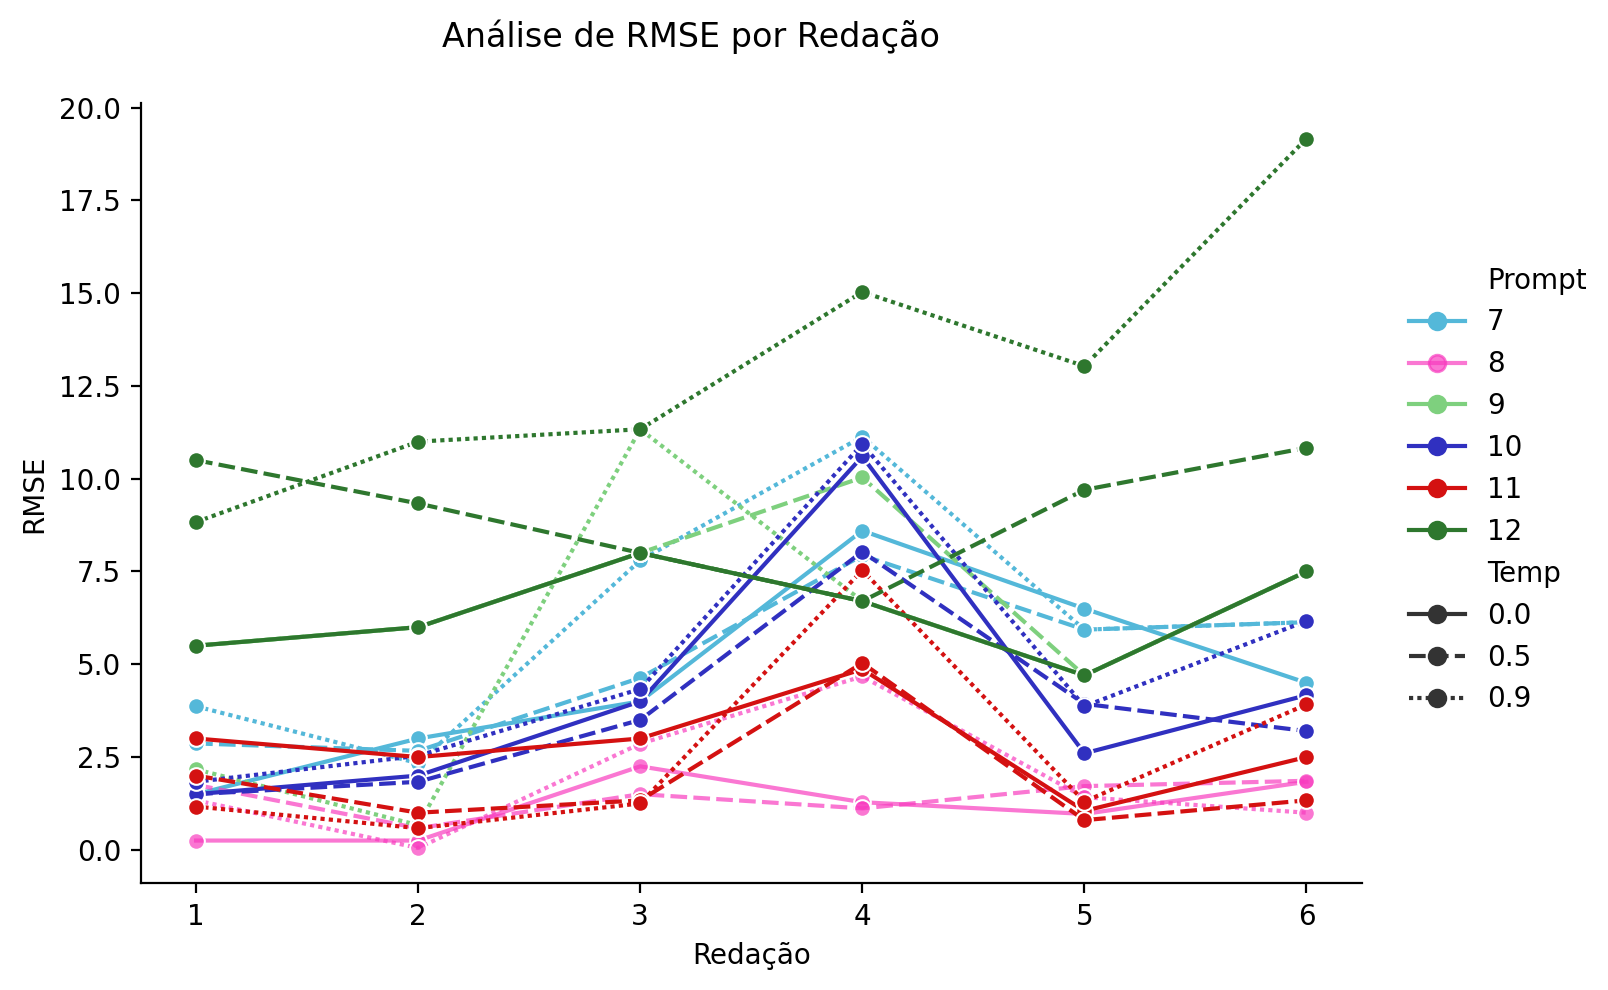

In [37]:
g = sns.relplot(
    data=df_merged,
    x="redacao",
    y="rmse",
    hue="prompt",
    style="temp",
    kind="line",
    marker="o",
    height=5,
    aspect=1.2,
    palette = ["#54B8D9", "#F83BBFB1", "#7ED07E", "#3030C0", "#D41111", "#2E772E"]
)

g._legend.set_bbox_to_anchor((1.15, 0.5))
g._legend.texts[0].set_text("Prompt")
g._legend.texts[7].set_text("Temp")

plt.suptitle("Análise de RMSE por Redação")
plt.tight_layout()
plt.xlabel("Redação")
plt.ylabel("RMSE")
plt.show()

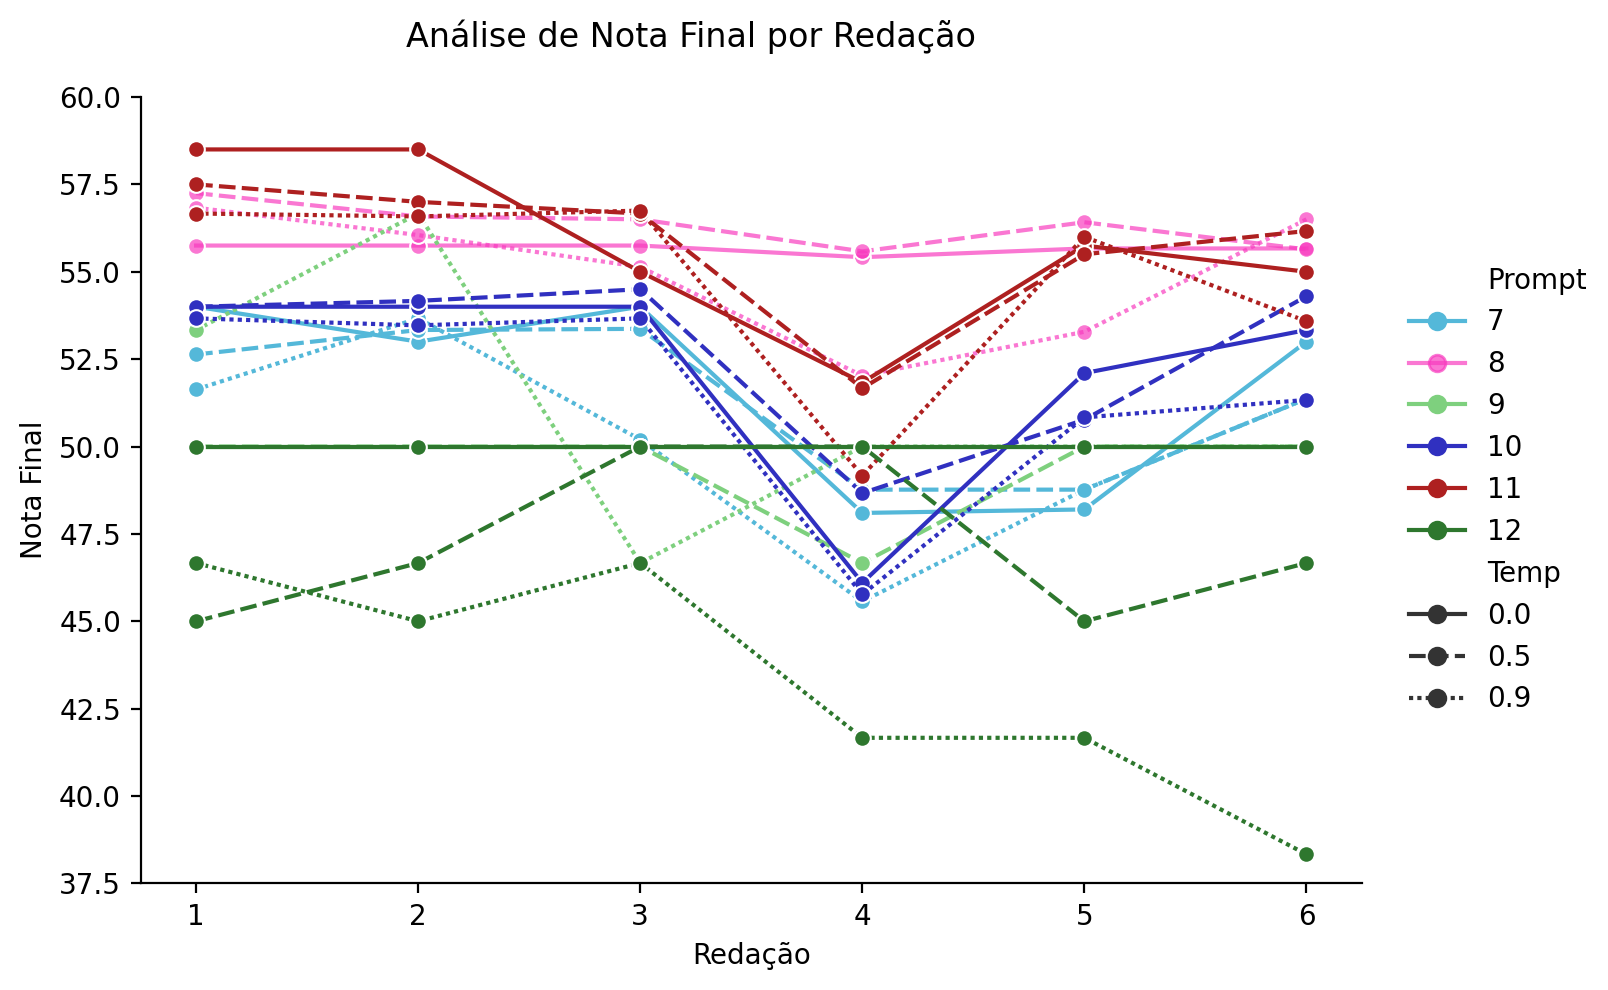

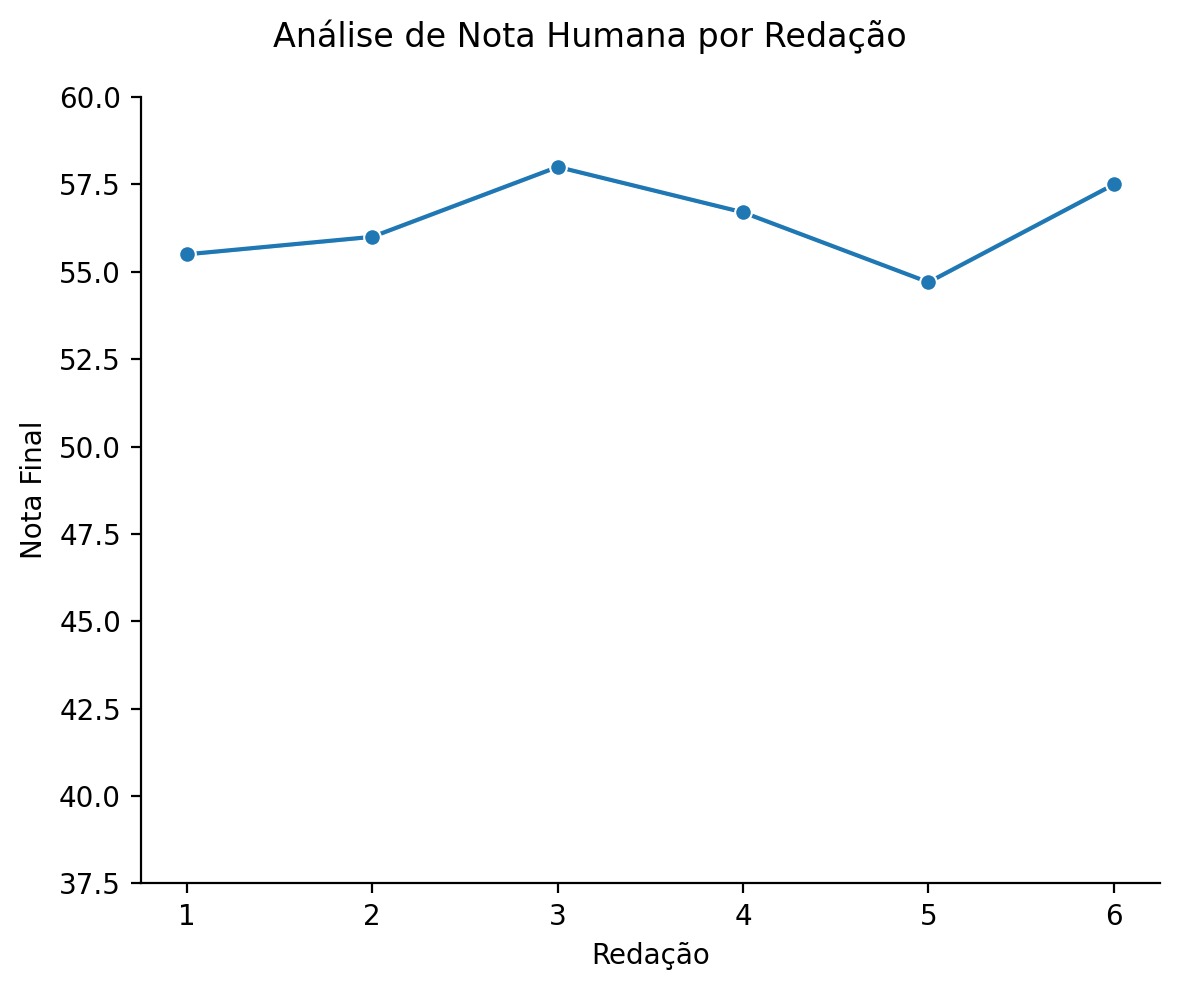

In [ ]:
g = sns.relplot(
    data=df_merged,
    x="redacao",
    y="nota_final",
    hue="prompt",
    style="temp",
    kind="line",
    marker="o",
    height=5,
    aspect=1.2,
    palette = ["#54B8D9", "#F83BBFB1", "#7ED07E", "#3030C0", "#D41111", "#2E772E"]
)

g._legend.set_bbox_to_anchor((1.15, 0.5))
g._legend.texts[0].set_text("Prompt")
g._legend.texts[7].set_text("Temp")

plt.suptitle("Análise de Nota Final por Redação")
plt.tight_layout()
plt.xlabel("Redação")
plt.ylabel("Nota Final")
plt.ylim(37.5, 60)
plt.show()

g = sns.relplot(
    data=df_merged,
    x="redacao",
    y="nota_humana",
    kind="line",
    marker="o",
    height=5,
    aspect=1.2,
)

plt.suptitle("Análise de Nota Humana por Redação")
plt.tight_layout()
plt.xlabel("Redação")
plt.ylabel("Nota Final")
plt.ylim(37.5, 60)
plt.show()

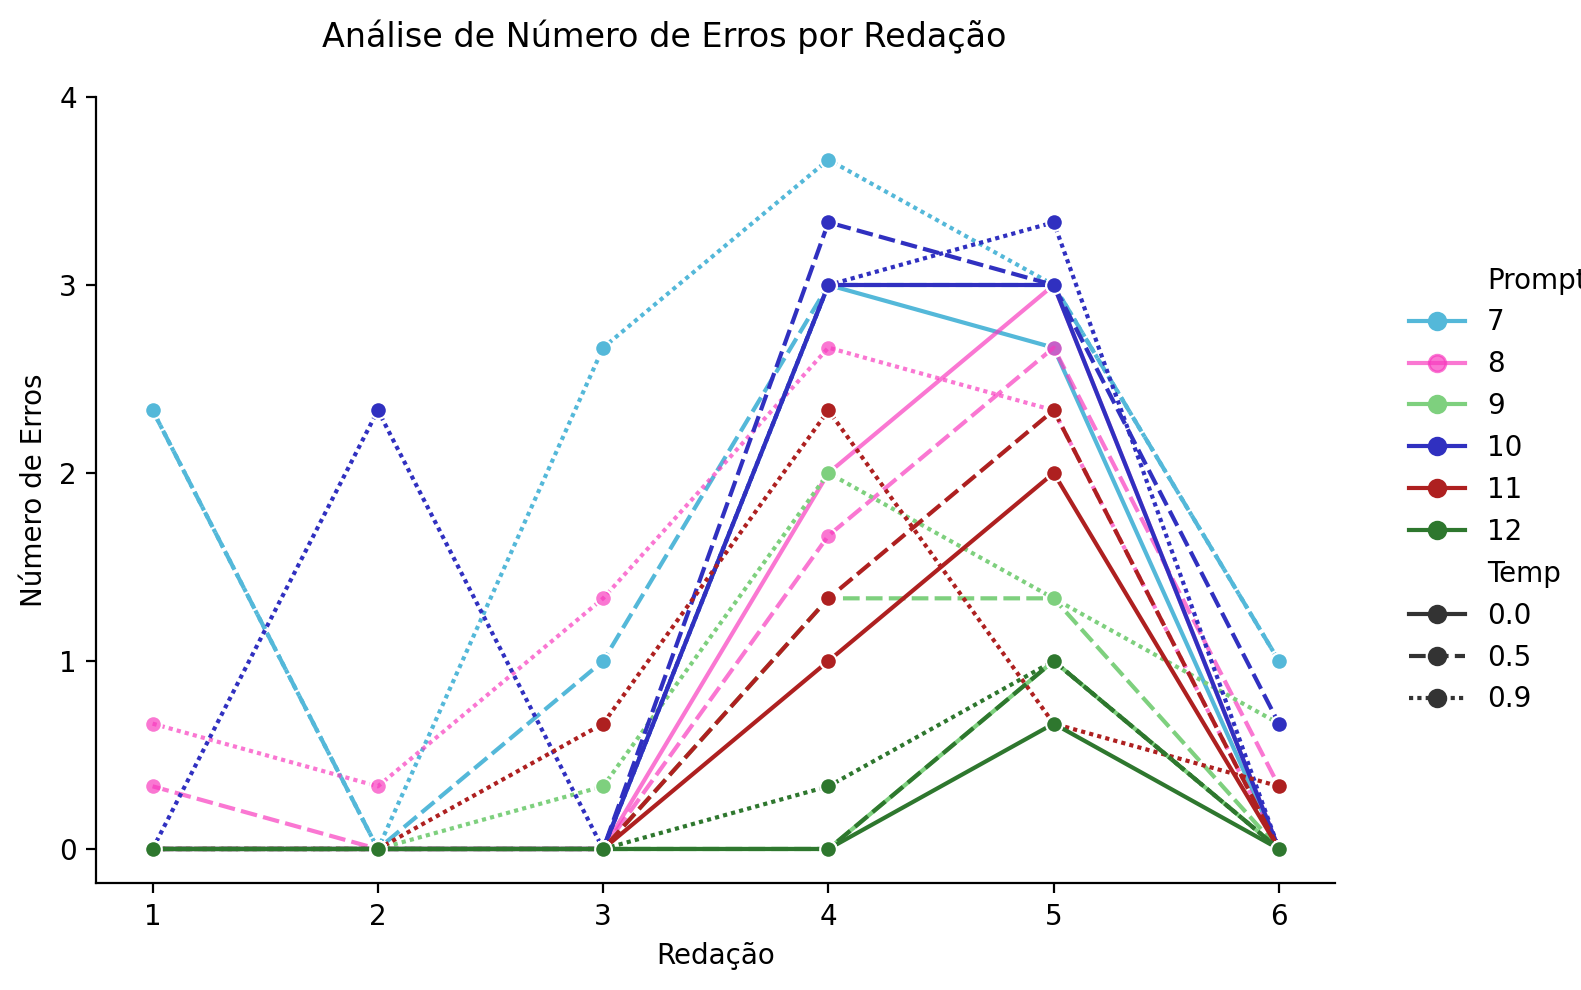

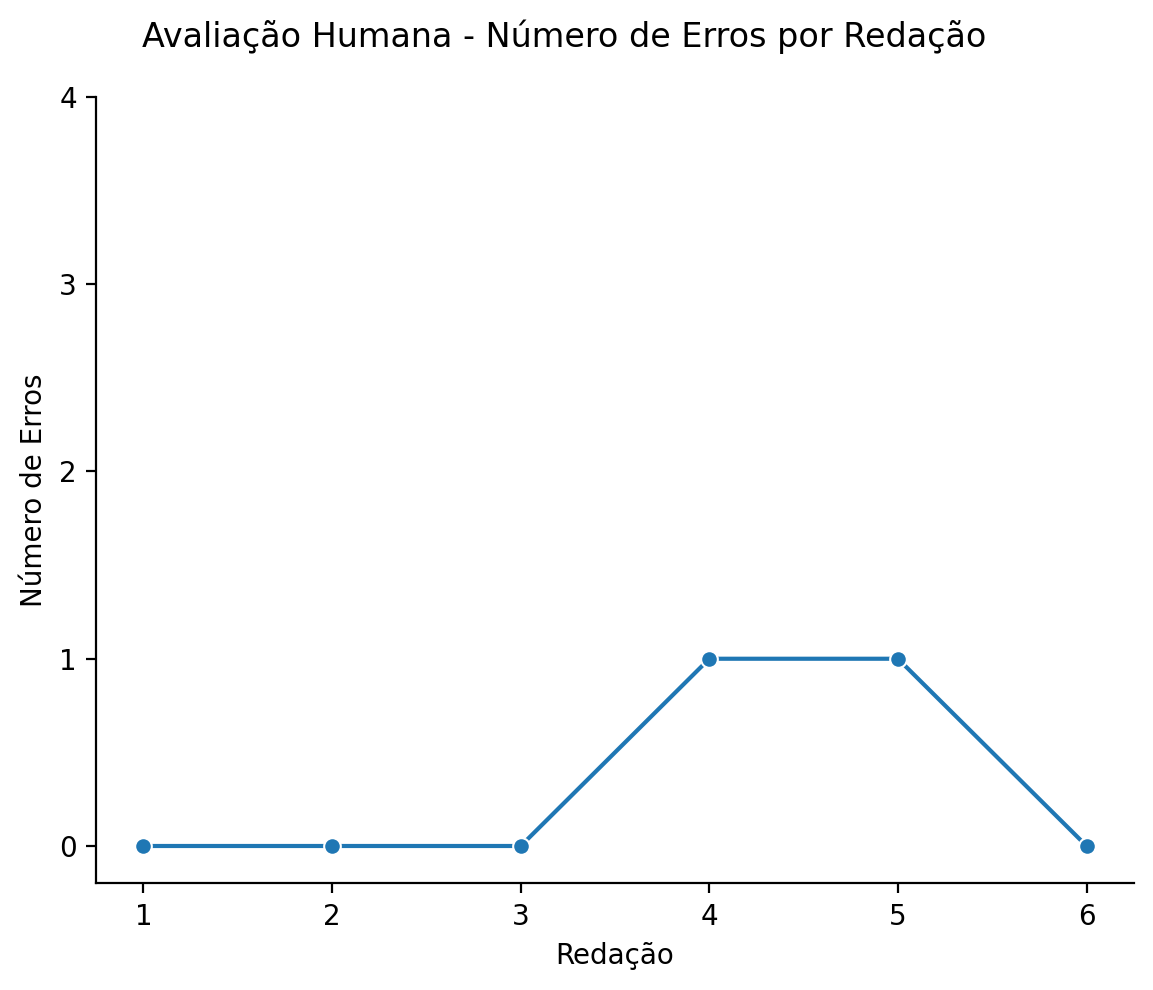

In [ ]:
g = sns.relplot(
    data=df_merged,
    x="redacao",
    y="num_errors",
    hue="prompt",
    style="temp",
    kind="line",
    marker="o",
    height=5,
    aspect=1.2,
    palette = ["#54B8D9", "#F83BBFB1", "#7ED07E", "#3030C0", "#D41111", "#2E772E"]
)

g._legend.set_bbox_to_anchor((1.15, 0.5))
g._legend.texts[0].set_text("Prompt")
g._legend.texts[7].set_text("Temp")

plt.suptitle("Análise de Número de Erros por Redação")
plt.tight_layout()
plt.xlabel("Redação")
plt.ylabel("Número de Erros")
plt.yticks([0, 1, 2, 3, 4])
plt.show()

g = sns.relplot(
    data=df_human,
    x="redacao",
    y="num_errors",
    kind="line",
    marker="o",
    height=5,
    aspect=1.2,
)

plt.suptitle("Avaliação Humana - Número de Erros por Redação")
plt.tight_layout()
plt.xlabel("Redação")
plt.ylabel("Número de Erros")
plt.yticks([0, 1, 2, 3, 4])
plt.ylim(-0.2, 4)
plt.show()